<a href="https://colab.research.google.com/github/Aditya127812/P.C.A_Task/blob/main/Task_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
org_data= pd.read_csv("US_Accidents_200k.csv")

/tmp/ipykernel_2124/1502025330.py:5: DtypeWarning: Columns (29,30,31,32,33,34,35,36,37,38,39,40,41) have mixed types. Specify dtype option on import or set low_memory=False.
  org_data= pd.read_csv("US_Accidents_200k.csv")


In [31]:
data= org_data.copy()

In [32]:
data.shape

(169900, 46)

In [33]:
data.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')

In [34]:
data.dtypes

,0
ID,object
Source,object
Severity,int64
Start_Time,object
End_Time,object
Start_Lat,float64
Start_Lng,float64
End_Lat,float64
End_Lng,float64
Distance(mi),float64


In [35]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169900 entries, 0 to 169899
Data columns (total 46 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     169900 non-null  object 
 1   Source                 169900 non-null  object 
 2   Severity               169900 non-null  int64  
 3   Start_Time             169900 non-null  object 
 4   End_Time               169900 non-null  object 
 5   Start_Lat              169900 non-null  float64
 6   Start_Lng              169900 non-null  float64
 7   End_Lat                95467 non-null   float64
 8   End_Lng                95467 non-null   float64
 9   Distance(mi)           169900 non-null  float64
 10  Description            169900 non-null  object 
 11  Street                 169656 non-null  object 
 12  City                   169892 non-null  object 
 13  County                 169899 non-null  object 
 14  State                  169899 non-nu

In [36]:
data.describe()

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,169900.000000,169900.000000,169900.000000,95467.000000,95467.000000,169900.000000,166338.000000,125910.000000,166113.000000,166812.000000,165997.000000,157251.000000,121437.000000
mean,2.211672,36.188973,-94.742208,36.269957,-95.764334,0.556978,61.700915,58.293055,64.821206,29.542321,9.090532,7.685179,0.008476
std,0.487555,5.081906,17.406465,5.278399,18.133673,1.757329,19.059225,22.459312,22.846284,1.003872,2.687431,5.681620,0.106883
min,1.000000,24.569963,-124.484914,24.570110,-124.484419,0.000000,-89.000000,-89.000000,2.000000,3.000000,0.000000,0.000000,0.000000
25%,2.000000,33.394469,-117.234934,33.462766,-117.796720,0.000000,49.000000,43.000000,48.000000,29.370000,10.000000,4.600000,0.000000
50%,2.000000,35.814529,-87.764383,36.249116,-88.035364,0.029000,64.000000,62.000000,67.000000,29.860000,10.000000,7.000000,0.000000
75%,2.000000,40.080534,-80.364835,40.195305,-80.254707,0.464000,76.000000,75.000000,84.000000,30.030000,10.000000,10.400000,0.000000
max,4.000000,48.971449,-68.365929,48.971488,-68.369387,183.119995,207.000000,207.000000,100.000000,52.760000,100.000000,812.000000,10.800000


In [37]:
data.head(10)

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-2803854,Source2,2,5/4/2018 9:37,5/4/2018 10:07,35.489677,-97.606712,NaN,NaN,0.000,...,False,False,False,False,False,False,Day,Day,Day,Day
1,A-91368,Source2,2,8/21/2016 12:39,8/21/2016 14:09,33.997856,-117.942055,NaN,NaN,0.000,...,False,False,False,False,False,False,Day,Day,Day,Day
2,A-5134091,Source1,2,49:54.0,07:04.0,35.143473,-81.653589,35.144900,-81.640144,0.766,...,False,False,False,False,False,False,Night,Night,Day,Day
3,A-1582325,Source3,2,1/8/2020 7:18,1/8/2020 7:48,34.015709,-117.339882,NaN,NaN,0.000,...,False,False,False,False,True,False,Day,Day,Day,Day
4,A-7768162,Source1,2,8/2/2019 7:04,8/2/2019 7:33,37.914260,-122.317560,37.907380,-122.315350,0.490,...,False,False,False,False,False,False,Day,Day,Day,Day
5,A-6719422,Source1,2,10/28/2020 23:44,10/29/2020 1:01,39.044412,-84.578536,39.038702,-84.591096,0.781,...,False,False,False,False,False,False,Night,Night,Night,Night
6,A-1767615,Source2,2,10/21/2019 18:53,10/21/2019 19:22,42.166309,-88.062759,NaN,NaN,0.000,...,False,False,False,False,True,False,Night,Night,Day,Day
7,A-2359972,Source2,2,1/25/2019 4:36,1/25/2019 5:06,34.156620,-80.807228,NaN,NaN,0.000,...,False,False,False,False,False,False,Night,Night,Night,Night
8,A-948421,Source2,2,8/3/2021 14:31,8/3/2021 15:01,33.056190,-80.193138,NaN,NaN,0.000,...,False,False,False,False,False,False,Day,Day,Day,Day
9,A-6032392,Source1,2,8/20/2021 14:52,8/20/2021 19:00,25.778011,-80.164842,25.787083,-80.187255,1.529,...,False,False,False,False,False,False,Day,Day,Day,Day


In [38]:
data.duplicated().sum()

np.int64(0)

In [39]:
data.isnull().sum()

,0
ID,0
Source,0
Severity,0
Start_Time,0
End_Time,0
Start_Lat,0
Start_Lng,0
End_Lat,74433
End_Lng,74433
Distance(mi),0


In [40]:
data = data.drop(columns=["ID", "Country"])

In [41]:
missing = data.isnull().sum()

missing[missing > 0].sort_values(ascending=False)

,0
End_Lat,74433
End_Lng,74433
Precipitation(in),48463
Wind_Chill(F),43990
Wind_Speed(mph),12649
Visibility(mi),3903
Wind_Direction,3872
Weather_Condition,3790
Humidity(%),3787
Temperature(F),3562


In [42]:
data["Wind_Speed(mph)"].fillna(data["Wind_Speed(mph)"].median(), inplace=True)
data["Pressure(in)"].fillna(data["Pressure(in)"].median(), inplace=True)
data["Temperature(F)"].fillna(data["Temperature(F)"].median(), inplace=True)
data["Humidity(%)"].fillna(data["Humidity(%)"].median(), inplace=True)
data["Visibility(mi)"].fillna(data["Visibility(mi)"].median(), inplace=True)
data["Precipitation(in)"].fillna(data["Precipitation(in)"].median(), inplace=True)
data["Wind_Chill(F)"].fillna(data["Wind_Chill(F)"].median(), inplace=True)

/tmp/ipykernel_2124/3100305516.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Wind_Speed(mph)"].fillna(data["Wind_Speed(mph)"].median(), inplace=True)
/tmp/ipykernel_2124/3100305516.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].meth

In [43]:
data["End_Lat"].isna().sum()
data["End_Lng"].isna().sum()

np.int64(74433)

In [44]:
data["Wind_Direction"]=data["Wind_Direction"].fillna(data["Wind_Direction"].mode()[0])
data["Weather_Condition"]=data["Weather_Condition"].fillna(data["Weather_Condition"].mode()[0])
data["Sunrise_Sunset"]=data["Sunrise_Sunset"].fillna(data["Sunrise_Sunset"].mode()[0])
data["Civil_Twilight"]=data["Civil_Twilight"].fillna(data["Civil_Twilight"].mode()[0])
data["Nautical_Twilight"]=data["Nautical_Twilight"].fillna(data["Nautical_Twilight"].mode()[0])
data["Astronomical_Twilight"]=data["Astronomical_Twilight"].fillna(data["Astronomical_Twilight"].mode()[0])
data["Airport_Code"]=data["Airport_Code"].fillna(data["Airport_Code"].mode()[0])
data["Street"]=data["Street"].fillna(data["Street"].mode()[0])
data["Timezone"]=data["Timezone"].fillna(data["Timezone"].mode()[0])
data["Zipcode"]=data["Zipcode"].fillna(data["Timezone"].mode()[0])
data["City"]=data["City"].fillna(data["City"].mode()[0])

In [45]:
data.isnull().sum().sort_values(ascending=False).head(20)

,0
End_Lat,74433
End_Lng,74433
Weather_Timestamp,2612
Roundabout,1
Stop,1
Traffic_Calming,1
Traffic_Signal,1
Turning_Loop,1
Amenity,1
State,1


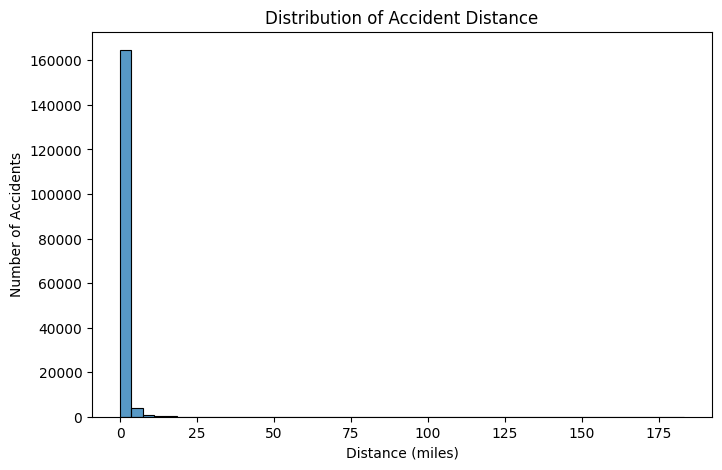

In [46]:
plt.figure(figsize=(8, 5))

sns.histplot(data["Distance(mi)"], bins=50)

plt.title("Distribution of Accident Distance")
plt.xlabel("Distance (miles)")
plt.ylabel("Number of Accidents")
plt.show()

Most accidents have a very small affected distance (close to 0 miles). As distance increases, the number of accidents drops sharply. A few accidents have very large distances, creating a right-skewed distribution.

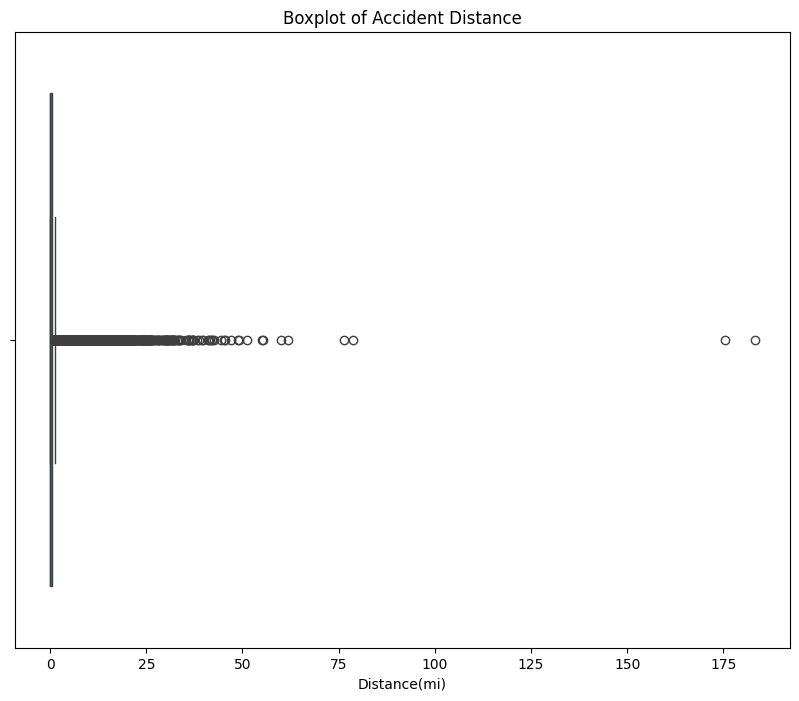

In [47]:
plt.figure(figsize=(10, 8))

sns.boxplot(x= data["Distance(mi)"])

plt.title("Boxplot of Accident Distance")
plt.show()

Most accident distances are very small, while several extreme outliers are present, including values above 50 miles and some near 180 miles.

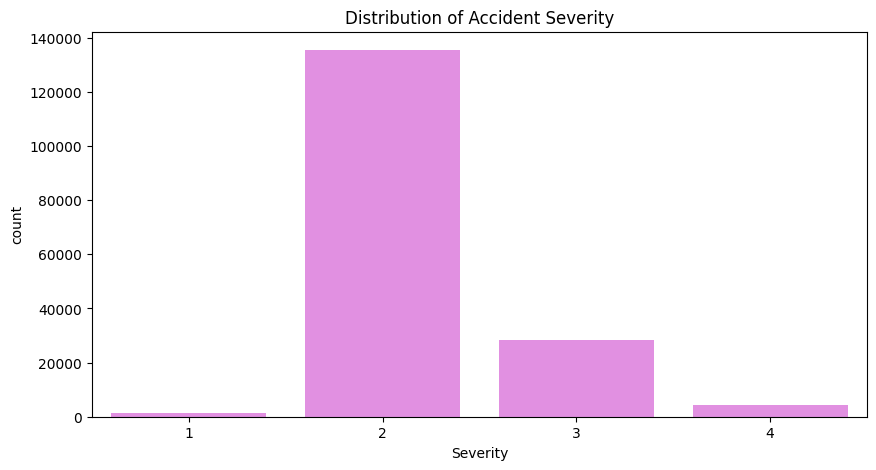

In [56]:
plt.figure(figsize=(10, 5))

sns.countplot(data= data, x = "Severity", color="violet")

plt.title("Distribution of Accident Severity")
plt.show()

Severity 2 accidents are by far the most common, followed by Severity 3. Severity 1 and 4 accidents are much less frequent.

In [49]:
data['Weather_Condition'].value_counts()

,count
Weather_Condition,
Fair,60087
Mostly Cloudy,22318
Clear,18030
Cloudy,17999
Partly Cloudy,15173
...,...
Squalls,1
Funnel Cloud,1
Snow and Sleet / Windy,1


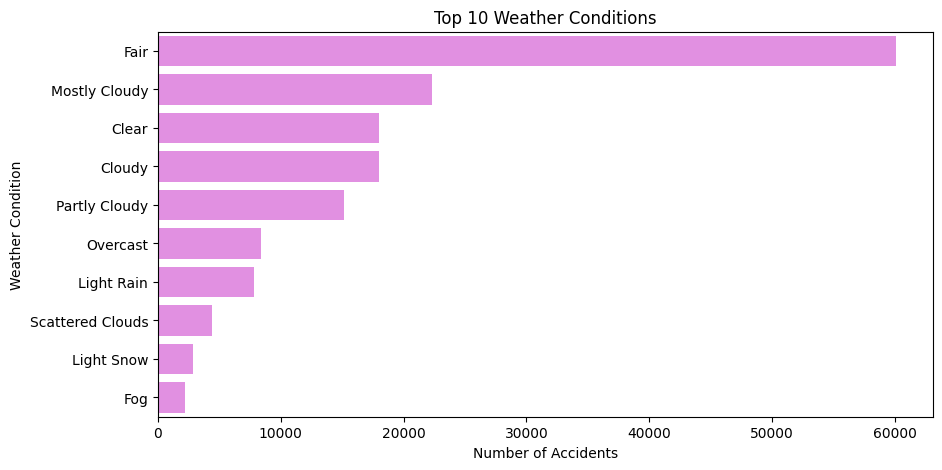

In [55]:
top_weather = data["Weather_Condition"].value_counts().head(10)

plt.figure(figsize=(10, 5))

sns.barplot( x=top_weather.values, y=top_weather.index, color="violet")

plt.title("Top 10 Weather Conditions")
plt.xlabel("Number of Accidents")
plt.ylabel("Weather Condition")
plt.show()

Fair weather has the highest number of accidents, followed by Mostly Cloudy and Clear conditions. Fog and Light Snow have the fewest among the top 10.

In [50]:
numerical_features = data.select_dtypes(include=[np.number]).columns

correlation = data[numerical_features].corr()

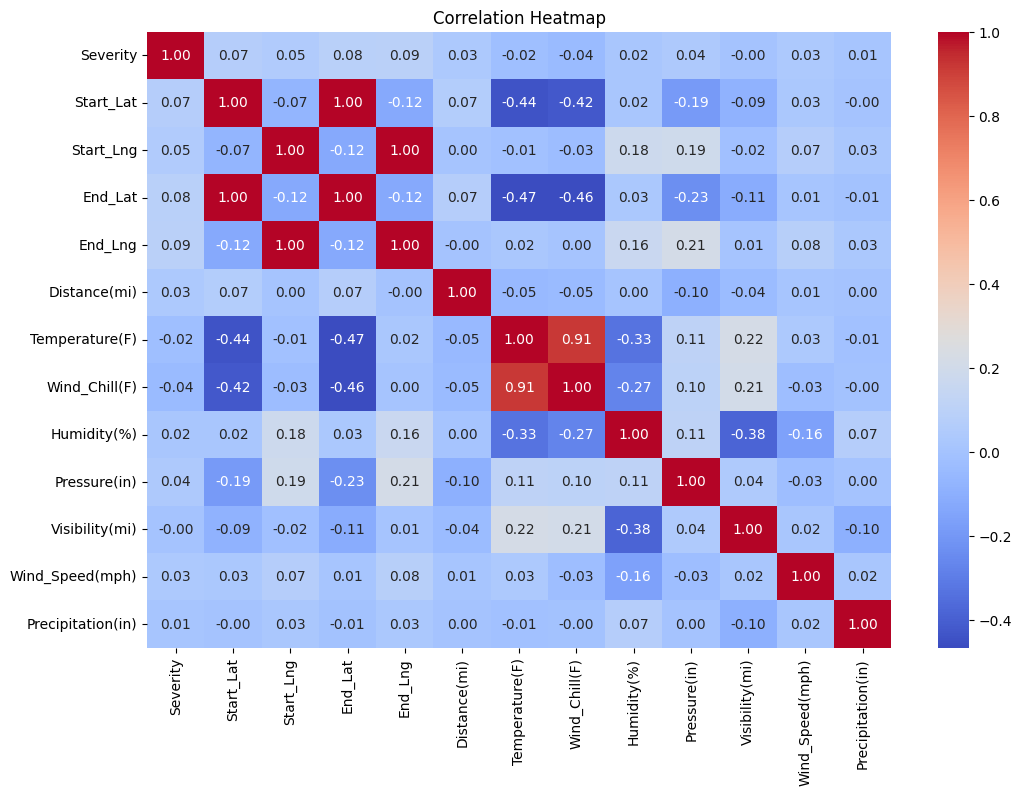

In [51]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [52]:
data["Start_Time"] = pd.to_datetime( data["Start_Time"], errors="coerce", format="mixed")

data["End_Time"] = pd.to_datetime( data["End_Time"], errors="coerce", format="mixed")

In [59]:
data["Year"] = data["Start_Time"].dt.year
data["Month"] = data["Start_Time"].dt.month
data["Hour"] = data["Start_Time"].dt.hour

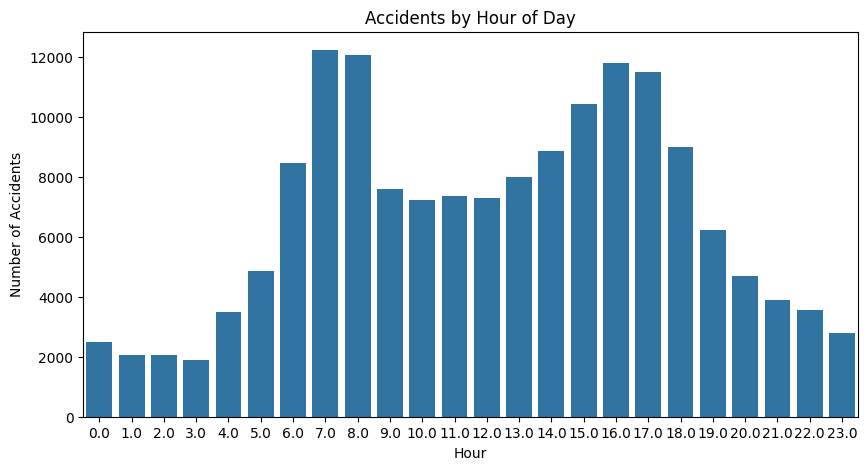

In [65]:
plt.figure(figsize=(10, 5))

sns.countplot(data =data, x="Hour" )

plt.title("Accidents by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Accidents")
plt.show()

The number of accidents varies significantly throughout the day. Accident frequency is relatively low during the early morning hours, especially around 1:00–3:00 AM. The number of accidents starts increasing from around 5:00 AM and reaches a major peak around 7:00–8:00 AM. It decreases during the late morning and then increases again during the afternoon, with another major peak around 4:00–5:00 PM. After 6:00 PM, the number of accidents gradually decreases.

->Overall, the graph shows that accidents are more frequent during the morning and evening periods, which may correspond to periods of higher road activity.